## 1. Library Import

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import re
from scipy import stats
import statsmodels.api as sm
from scipy.stats import chi2_contingency



ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## 2. Data Import

In [3]:
df = pd.read_csv("Exp_pensee2.csv", sep = ",")
pd.set_option("display.max_column", None)
display(df)

,Date,Birth,Gender,Country,Economy,Religion,Study,Violinist,Happiness,Abortion,Disappointed,Moral_Philosophy,Unnamed: 12
0,27/05/2024 18:05:46,2005,Woman [Femme],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01/06/2024 18:15:18,1970,Man [Homme],France,Above average [Au-dessus de la moyenne],No [Non],"MS, MA [Maîtrise]","No, I’m not asking to be unplugged [Non, je n...","Yes, I connect to the machine [Oui, je me bran...",For [Pour],"Yes, I have felt disapointed [Oui, je me suis ...",Yes [Oui],NaN
2,01/06/2024 18:44:17,2005,Woman [Femme],France,Above average [Au-dessus de la moyenne],No [Non],"A level, NVQ level 3 [Baccalauréat]","Yes, I ask to be unplugged [Oui, je demande à...","Yes, I connect to the machine [Oui, je me bran...",For [Pour],"Yes, I have felt disapointed [Oui, je me suis ...",Yes [Oui],NaN
3,01/06/2024 18:48:21,2003,Woman [Femme],france,In the average [Dans la moyenne],No [Non],"A level, NVQ level 3 [Baccalauréat]","Yes, I ask to be unplugged [Oui, je demande à...","Yes, I connect to the machine [Oui, je me bran...",For [Pour],"Yes, I have felt disapointed [Oui, je me suis ...",Yes [Oui],NaN
4,01/06/2024 18:49:43,2005,Woman [Femme],France,In the average [Dans la moyenne],No [Non],"A level, NVQ level 3 [Baccalauréat]","Yes, I ask to be unplugged [Oui, je demande à...","No, I don't connect to the machine [Non, je ne...",For [Pour],I haven't been in this situation [Je n'ai pas ...,I don't know [Je ne sais pas],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,14/06/2024 14:50:02,1995,Man [Homme],France,Above average [Au-dessus de la moyenne],Yes [Oui],"MS and MA NVQ, master's degree in engineering ...","No, I’m not asking to be unplugged [Non, je n...","No, I don't connect to the machine [Non, je ne...",I don't know [Je ne sais pas],"No, I haven't felt disapointed [Non, je ne me ...",No [Non],NaN
110,14/06/2024 14:52:16,1998,Woman [Femme],swiss,In the average [Dans la moyenne],I don't know [Je ne sais pas],"MS, MA [Maîtrise]","No, I’m not asking to be unplugged [Non, je n...","No, I don't connect to the machine [Non, je ne...",For [Pour],"Yes, I have felt disapointed [Oui, je me suis ...",No [Non],NaN
111,14/06/2024 17:42:19,2000,Woman [Femme],france,Above average [Au-dessus de la moyenne],No [Non],"MS and MA NVQ, master's degree in engineering ...","Yes, I ask to be unplugged [Oui, je demande à...","Yes, I connect to the machine [Oui, je me bran...",For [Pour],I haven't been in this situation [Je n'ai pas ...,Yes [Oui],NaN
112,14/06/2024 17:53:23,2001,Woman [Femme],France,In the average [Dans la moyenne],Prefer not to answer [Ne préfère pas répondre],"MS and MA NVQ, master's degree in engineering ...","No, I’m not asking to be unplugged [Non, je n...","No, I don't connect to the machine [Non, je ne...",For [Pour],"Yes, I have felt disapointed [Oui, je me suis ...",Yes [Oui],NaN


## 3. Data Manipulation

In [4]:
# Fonction pour supprimer le contenu entre crochets dans une ligne
def remove_brackets_content(line):
    return re.sub(r'\[.*?\]', '', line)

# Lire toutes les lignes du fichier et nettoyer le contenu entre crochets
with open("Exp_pensee2.csv", 'r') as file:
    lines = file.readlines()

# Appliquer la fonction à chaque ligne
cleaned_lines = [remove_brackets_content(line) for line in lines]

# Sauvegarder les lignes nettoyées dans un nouveau fichier temporaire
with open("temp_experience_pensee_cleaned.csv", 'w') as temp_file:
    temp_file.writelines(cleaned_lines)

# Charger le fichier CSV nettoyé dans un dataframe
df = pd.read_csv("temp_experience_pensee_cleaned.csv")

# Colonnes où les remplacements doivent être effectués
columns_to_replace = ['Violinist', 'Happiness', 'Disappointed', 'Moral_Philosophy']  # Remplacez par les colonnes réelles concernées

# Fonction pour appliquer les remplacements en gardant seulement "Yes" ou "No"
def replace_yes_no(value):
    if pd.isna(value):
        return value  # Si la valeur est NaN, la laisser inchangée
    elif re.search(r'\bYes\b', str(value), flags=re.IGNORECASE):
        return "Yes"
    elif re.search(r'\bNo\b', str(value), flags=re.IGNORECASE):
        return "No"
    else:
        return value  # Retourner la valeur telle quelle si elle ne contient pas "Yes" ou "No"

# Appliquer la fonction à toutes les colonnes spécifiées
df[columns_to_replace] = df[columns_to_replace].applymap(replace_yes_no)

# Remplacer des valeurs spécifiques
df.replace({"07.10.2006": "2006",
            "25/08/2025": "",
            "Above average": "Above_average",
            "In the average": "In_the_average",
            "Below average": "Below_average"}, inplace=True)

# Remplacer les chaînes 'nan' par des valeurs NA de pandas
df_clean = df.replace('nan', pd.NA)

# Nettoyer les colonnes catégorielles
categorical_columns = ['Gender', 'Religion', 'Economy', 'Happiness', 'Violinist', 'Moral_Philosophy']
for column in categorical_columns:
    df_clean[column] = df_clean[column].astype(str).str.strip()

# Nettoyer et convertir la colonne 'Birth' en numérique (année de naissance)
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'], errors='coerce')

# Supprimer les lignes avec des valeurs NA dans les colonnes catégorielles
df_clean = df_clean.dropna(subset=categorical_columns)

# Afficher le dataframe pour vérifier les modifications
pd.set_option("display.max_columns", None)
display(df_clean)


C:\Users\Léna\AppData\Local\Temp\ipykernel_12516\113251659.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[columns_to_replace] = df[columns_to_replace].applymap(replace_yes_no)


,Date,Birth,Gender,Country,Economy,Religion,Study,Violinist,Happiness,Abortion,Disappointed,Moral_Philosophy,Unnamed: 12
0,27/05/2024 18:05:46,2005.0,Woman,NaN,nan,nan,NaN,nan,nan,NaN,NaN,nan,NaN
1,01/06/2024 18:15:18,1970.0,Man,France,Above average,No,"MS, MA",No,Yes,For,Yes,Yes,NaN
2,01/06/2024 18:44:17,2005.0,Woman,France,Above average,No,"A level, NVQ level 3",Yes,Yes,For,Yes,Yes,NaN
3,01/06/2024 18:48:21,2003.0,Woman,france,In the average,No,"A level, NVQ level 3",Yes,Yes,For,Yes,Yes,NaN
4,01/06/2024 18:49:43,2005.0,Woman,France,In the average,No,"A level, NVQ level 3",Yes,No,For,I haven't been in this situation,I don't know,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,14/06/2024 14:50:02,1995.0,Man,France,Above average,Yes,"MS and MA NVQ, master's degree in engineering ...",No,No,I don't know,No,No,NaN
110,14/06/2024 14:52:16,1998.0,Woman,swiss,In the average,I don't know,"MS, MA",No,No,For,Yes,No,NaN
111,14/06/2024 17:42:19,2000.0,Woman,france,Above average,No,"MS and MA NVQ, master's degree in engineering ...",Yes,Yes,For,I haven't been in this situation,Yes,NaN
112,14/06/2024 17:53:23,2001.0,Woman,France,In the average,Prefer not to answer,"MS and MA NVQ, master's degree in engineering ...",No,No,For,Yes,Yes,NaN


## 4. Data Description

C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

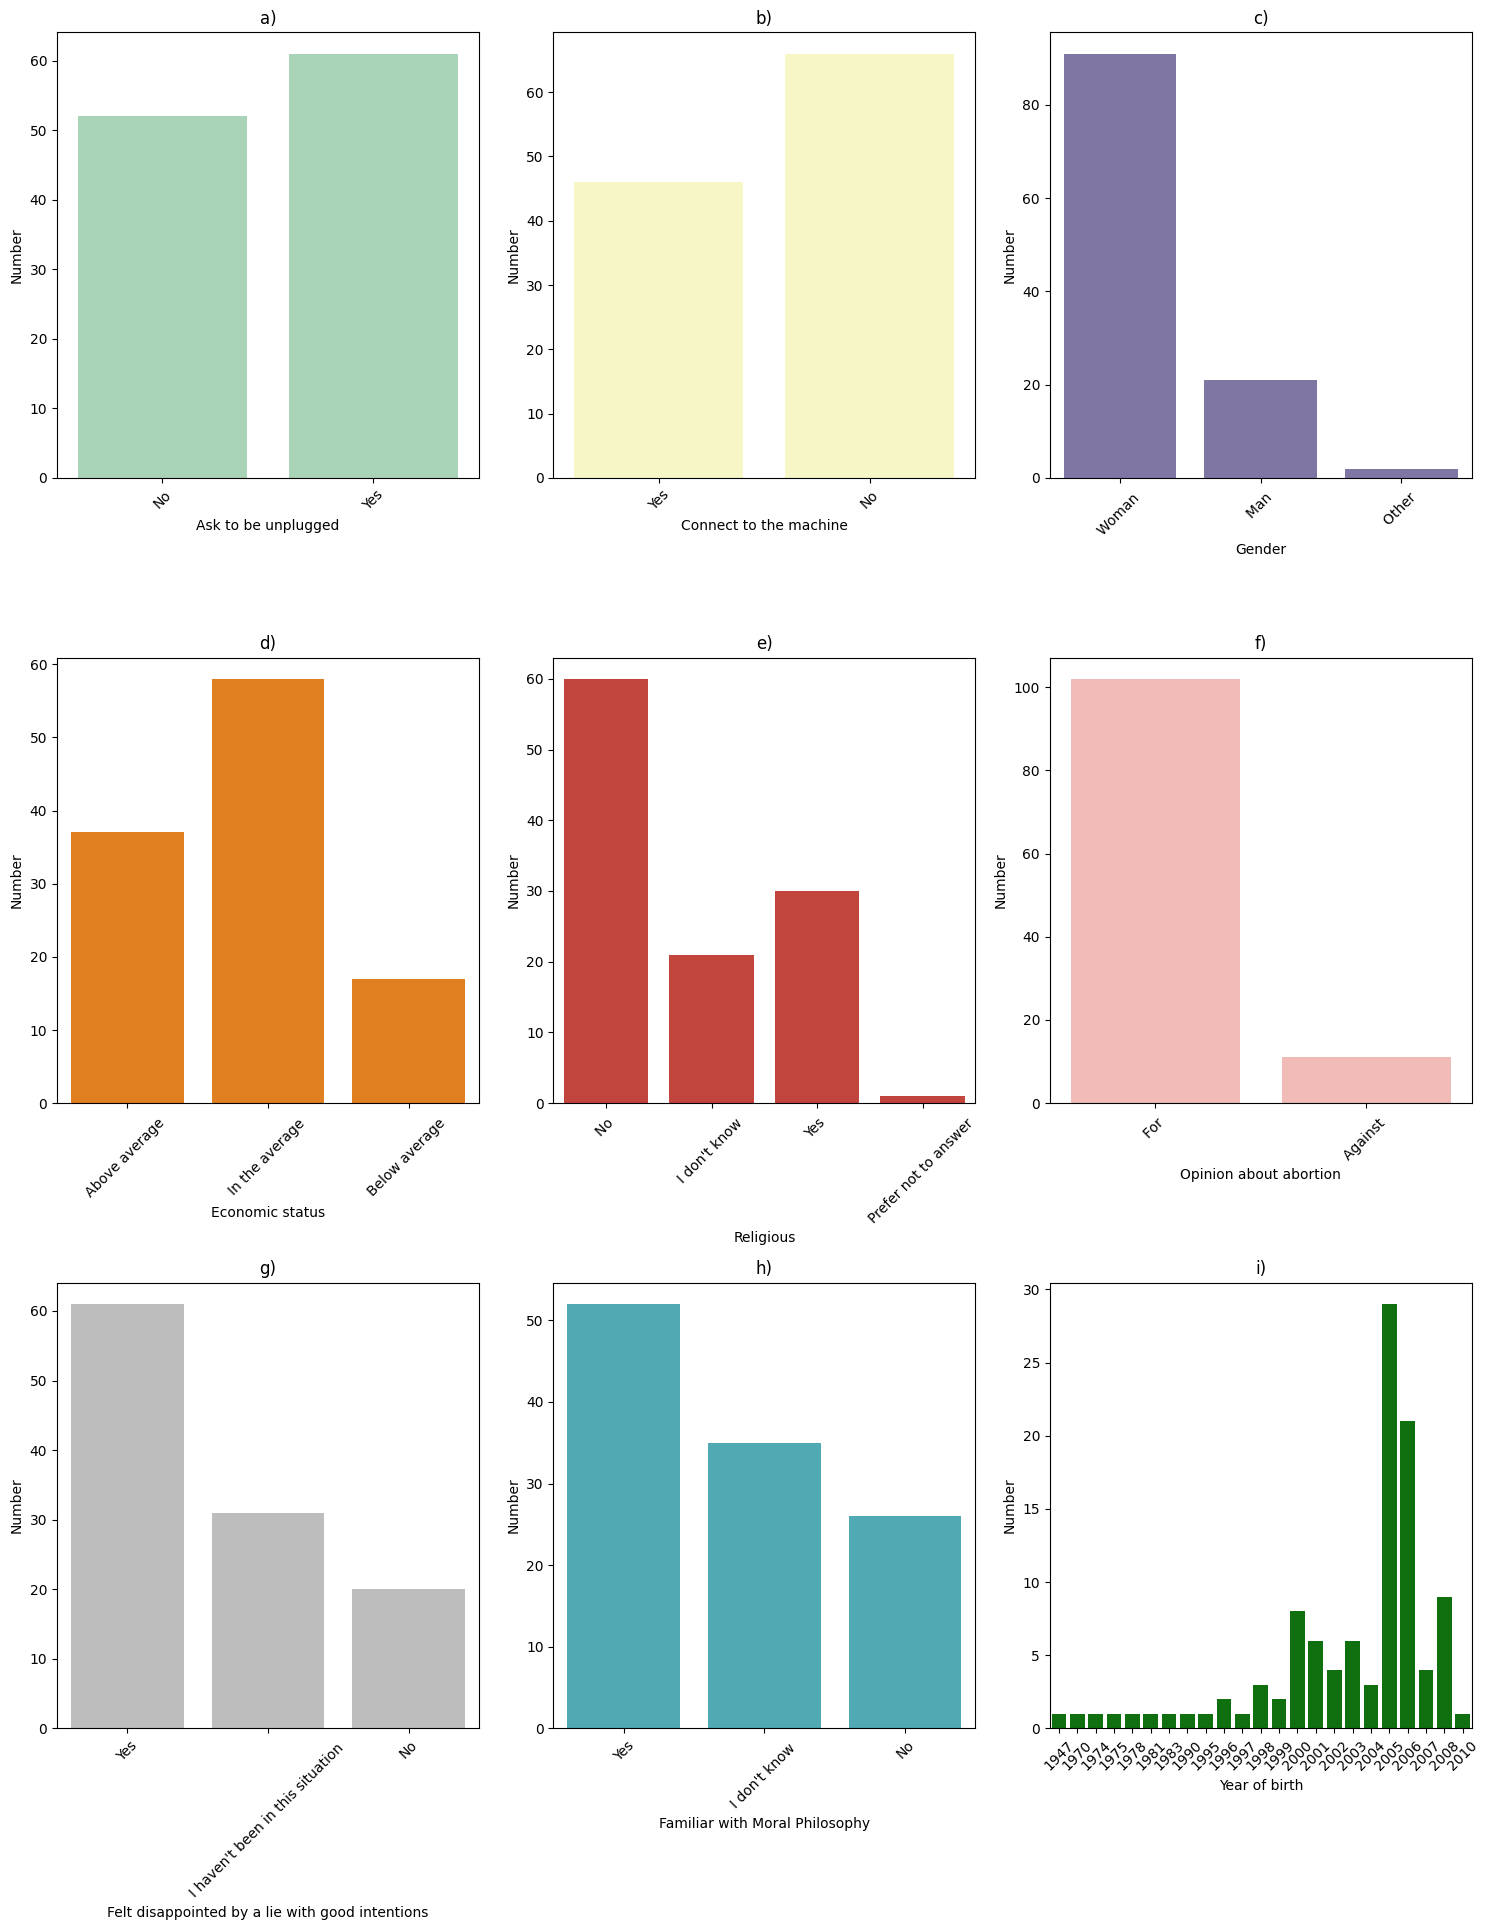

In [19]:
# Define the overall figure size and the main title
fig1 = plt.figure(figsize=(15, 20))

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Define a list of pastel color palettes for each chart
palettes = ['#a1dab4', '#41b6c4', '#7b6eac', '#ff7f00', '#d73027', '#fdae00', '#fbb4ae', '#bdbdbd', '#fffebf', '#77dd77']
palette_for_graphic_9 = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']  # New palette for chart 9

# Chart 1: Number of responses regarding the violinist's experience
plt.subplot(3, 3, 1)
sns.countplot(x='Violinist', data=df_clean, palette=[palettes[0]])
plt.title('a)')
plt.xlabel('Ask to be unplugged')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 2: Number of responses regarding the happiness machine experience
plt.subplot(3, 3, 2)
sns.countplot(x='Happiness', data=df_clean, palette=[palettes[8]])
plt.title('b)')
plt.xlabel('Connect to the machine')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 3: Distribution of gender
plt.subplot(3, 3, 3)
sns.countplot(x='Gender', data=df_clean, palette=[palettes[2]])
plt.title('c)')
plt.xlabel('Gender')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 4: Distribution of economic status
plt.subplot(3, 3, 4)
sns.countplot(x='Economy', data=df_clean, palette=[palettes[3]])
plt.title('d)')
plt.xlabel('Economic status')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 5: Distribution of religious persons
plt.subplot(3, 3, 5)
sns.countplot(x='Religion', data=df_clean, palette=[palettes[4]])
plt.title('e)')
plt.xlabel('Religious')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 6: Distribution of opinion on abortion
plt.subplot(3, 3, 6)
sns.countplot(x='Abortion', data=df_clean, palette=[palettes[6]])
plt.title('f)')
plt.xlabel('Opinion about abortion')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 7: Distribution of people disappointed by someone who lied to them with good intentions
plt.subplot(3, 3, 7)
sns.countplot(x='Disappointed', data=df_clean, palette=[palettes[7]])
plt.title('g)')
plt.xlabel('Felt disappointed by a lie with good intentions')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Chart 8: Distribution of familiarity with moral philosophy
plt.subplot(3, 3, 8)
sns.countplot(x='Moral_Philosophy', data=df_clean, palette=[palettes[1]])  # Set in yellow
plt.title('h)')
plt.xlabel('Familiar with Moral Philosophy')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Filter null or empty values for chart 9
filtered_df = df[df['Birth'].notnull() & (df['Birth'] != '')]

# Chart 9: Distribution of the year of birth
plt.subplot(3, 3, 9)
sns.countplot(x='Birth', data=filtered_df, order=sorted(filtered_df['Birth'].unique()), color='green')
plt.title('i)')
plt.xlabel('Year of birth')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.tight_layout()

# Adjust the spacing for the main title
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

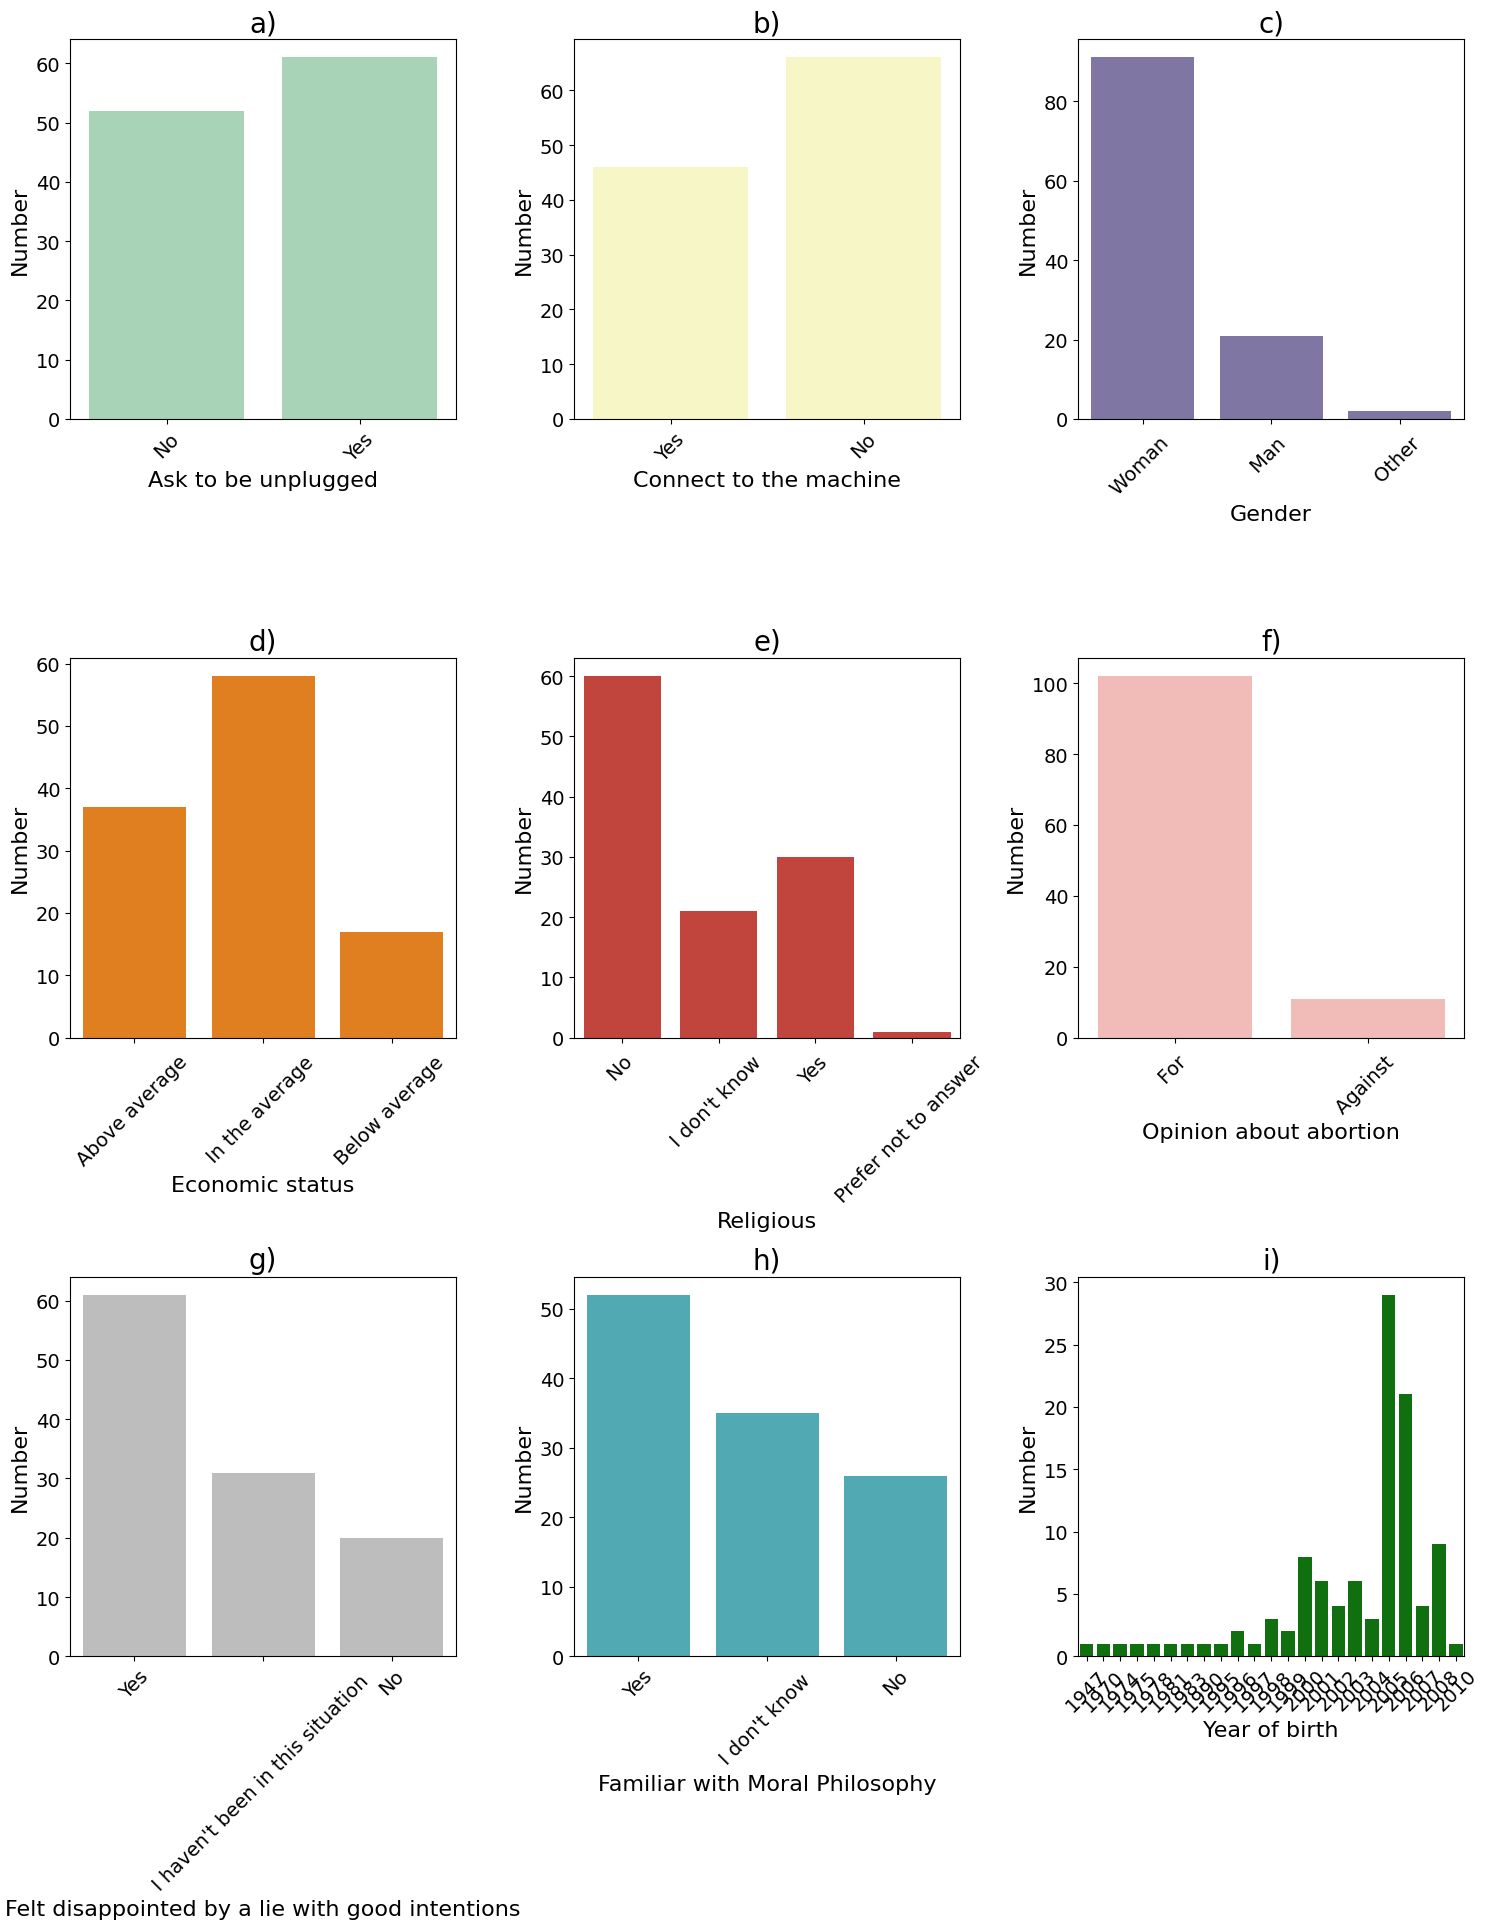

In [22]:
# Define the overall figure size and the main title
fig1 = plt.figure(figsize=(15, 20))

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Define a list of pastel color palettes for each chart
palettes = ['#a1dab4', '#41b6c4', '#7b6eac', '#ff7f00', '#d73027', '#fdae00', '#fbb4ae', '#bdbdbd', '#fffebf', '#77dd77']
palette_for_graphic_9 = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']  # New palette for chart 9

# Increase font sizes
title_fontsize = 20
label_fontsize = 16
tick_fontsize = 14

# Chart 1: Number of responses regarding the violinist's experience
plt.subplot(3, 3, 1)
sns.countplot(x='Violinist', data=df_clean, palette=[palettes[0]])
plt.title('a)', fontsize=title_fontsize)
plt.xlabel('Ask to be unplugged', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 2: Number of responses regarding the happiness machine experience
plt.subplot(3, 3, 2)
sns.countplot(x='Happiness', data=df_clean, palette=[palettes[8]])
plt.title('b)', fontsize=title_fontsize)
plt.xlabel('Connect to the machine', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 3: Distribution of gender
plt.subplot(3, 3, 3)
sns.countplot(x='Gender', data=df_clean, palette=[palettes[2]])
plt.title('c)', fontsize=title_fontsize)
plt.xlabel('Gender', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 4: Distribution of economic status
plt.subplot(3, 3, 4)
sns.countplot(x='Economy', data=df_clean, palette=[palettes[3]])
plt.title('d)', fontsize=title_fontsize)
plt.xlabel('Economic status', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 5: Distribution of religious persons
plt.subplot(3, 3, 5)
sns.countplot(x='Religion', data=df_clean, palette=[palettes[4]])
plt.title('e)', fontsize=title_fontsize)
plt.xlabel('Religious', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 6: Distribution of opinion on abortion
plt.subplot(3, 3, 6)
sns.countplot(x='Abortion', data=df_clean, palette=[palettes[6]])
plt.title('f)', fontsize=title_fontsize)
plt.xlabel('Opinion about abortion', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 7: Distribution of people disappointed by someone who lied to them with good intentions
plt.subplot(3, 3, 7)
sns.countplot(x='Disappointed', data=df_clean, palette=[palettes[7]])
plt.title('g)', fontsize=title_fontsize)
plt.xlabel('Felt disappointed by a lie with good intentions', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Chart 8: Distribution of familiarity with moral philosophy
plt.subplot(3, 3, 8)
sns.countplot(x='Moral_Philosophy', data=df_clean, palette=[palettes[1]])  # Set in yellow
plt.title('h)', fontsize=title_fontsize)
plt.xlabel('Familiar with Moral Philosophy', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Filter null or empty values for chart 9
filtered_df = df[df['Birth'].notnull() & (df['Birth'] != '')]

# Chart 9: Distribution of the year of birth
plt.subplot(3, 3, 9)
sns.countplot(x='Birth', data=filtered_df, order=sorted(filtered_df['Birth'].unique()), color='green')
plt.title('i)', fontsize=title_fontsize)
plt.xlabel('Year of birth', fontsize=label_fontsize)
plt.ylabel('Number', fontsize=label_fontsize)
plt.xticks(rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()

# Adjust the spacing for the main title
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

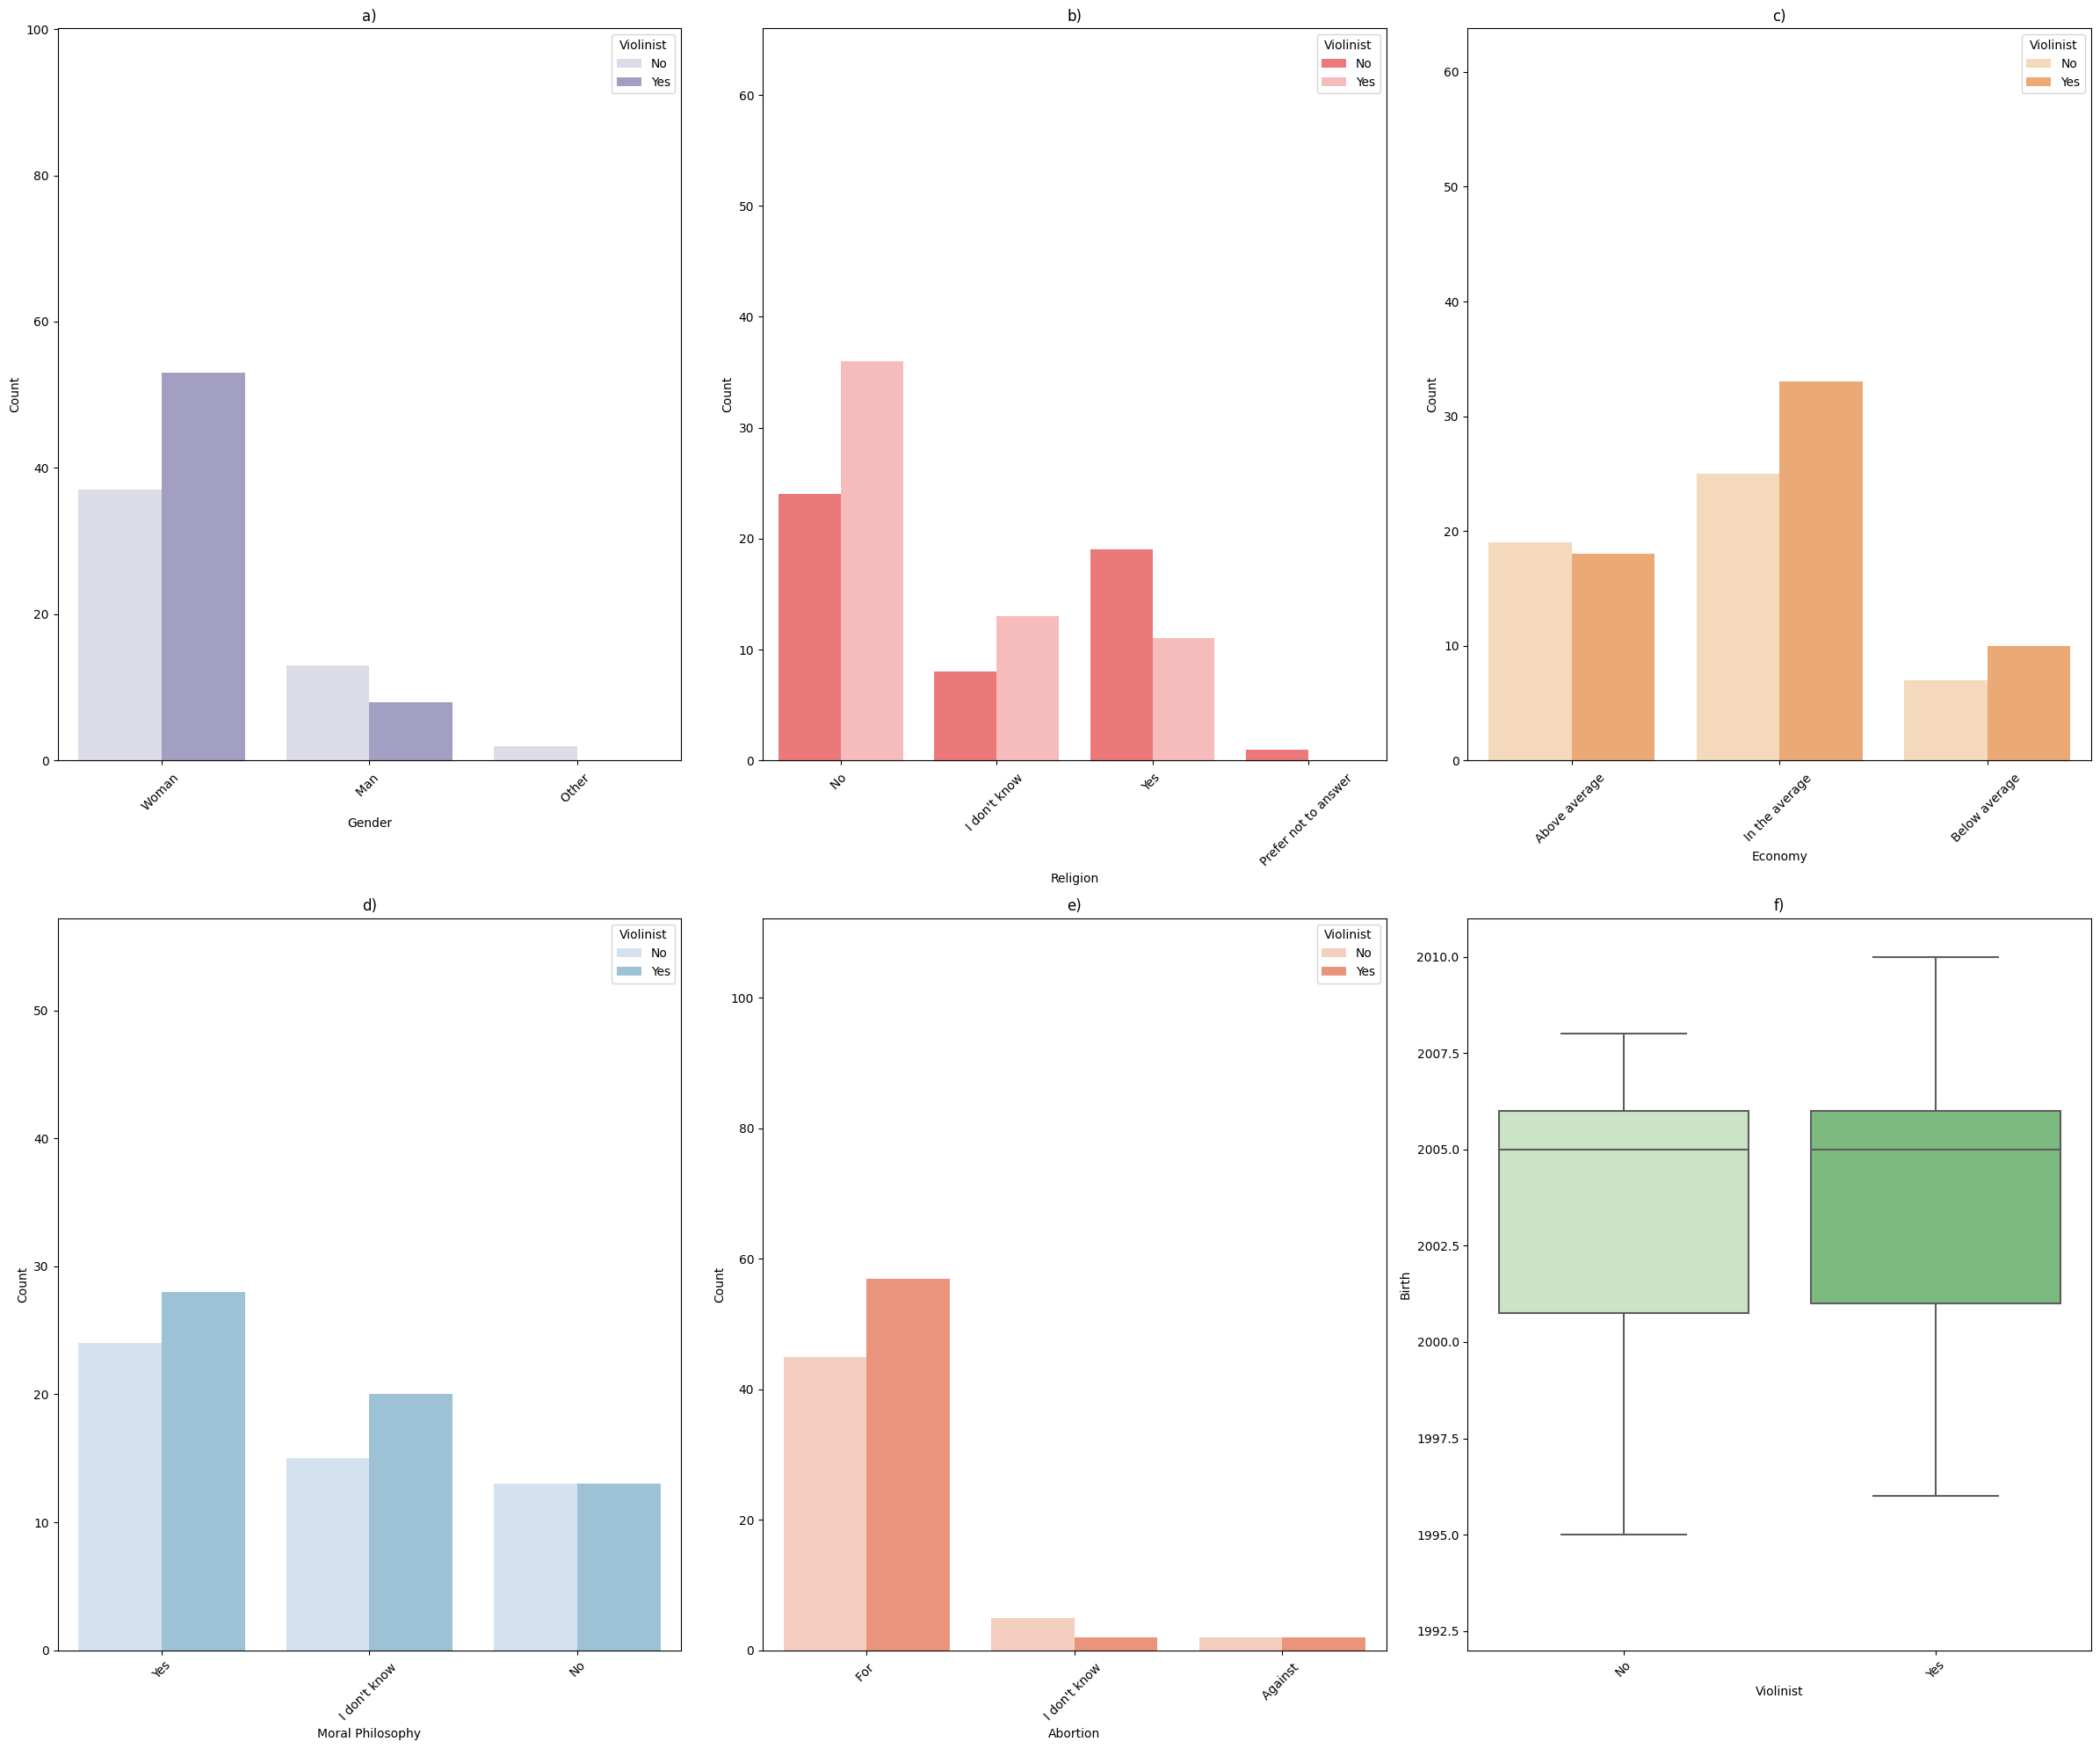

In [6]:
# Define the size of the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 20))

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'], errors='coerce')

# Catplot for Gender vs answers to the violinist experience of thought
gender_palette = sns.color_palette("Purples", len(df_clean['Gender'].unique()))
sns.countplot(x='Gender', hue='Violinist', data=df_clean, palette=gender_palette, ax=axes[0, 0])
axes[0, 0].set_title('a)')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim(0, df_clean['Gender'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Religion vs answers to the violinist experience of thought
vivid_reds = ["#FF6666", "#FFB3B3"]
religion_palette = sns.color_palette(vivid_reds, len(df_clean['Religion'].unique()))
sns.countplot(x='Religion', hue='Violinist', data=df_clean, palette=religion_palette, ax=axes[0, 1])
axes[0, 1].set_title('b)')
axes[0, 1].set_xlabel('Religion')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim(0, df_clean['Religion'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Economy vs answers to the violinist experience of thought
economy_palette = sns.color_palette("Oranges", len(df_clean['Economy'].unique()))
sns.countplot(x='Economy', hue='Violinist', data=df_clean, palette=economy_palette, ax=axes[0, 2])
axes[0, 2].set_title('c)')
axes[0, 2].set_xlabel('Economy')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].set_ylim(0, df_clean['Economy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Moral Philosophy vs answers to the violinist experience of thought
moral_palette = sns.color_palette("Blues", len(df_clean['Moral_Philosophy'].unique()))
sns.countplot(x='Moral_Philosophy', hue='Violinist', data=df_clean, palette=moral_palette, ax=axes[1, 0])
axes[1, 0].set_title('d)')
axes[1, 0].set_xlabel('Moral Philosophy')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, df_clean['Moral_Philosophy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Abortion vs answers to the violinist experience of thought
abortion_palette = sns.color_palette("Reds", len(df_clean['Abortion'].unique()))
sns.countplot(x='Abortion', hue='Violinist', data=df_clean, palette=abortion_palette, ax=axes[1, 1])
axes[1, 1].set_title('e)')
axes[1, 1].set_xlabel('Abortion')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim(0, df_clean['Abortion'].value_counts().max() * 1.1)  # adjust y-scale

# Boxplot for Birth vs answers to the violinist experience of thought
birth_palette = sns.color_palette("Greens", len(df_clean['Violinist'].unique()))
sns.boxplot(x='Violinist', y='Birth', data=df_clean, palette=birth_palette, ax=axes[1, 2])
axes[1, 2].set_title('f)')
axes[1, 2].set_xlabel('Violinist')
axes[1, 2].set_ylabel('Birth')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_ylim(1992, 2011)  # Set y-axis limit

# Adjust the spacing between subplots to avoid overlap of titles and labels
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

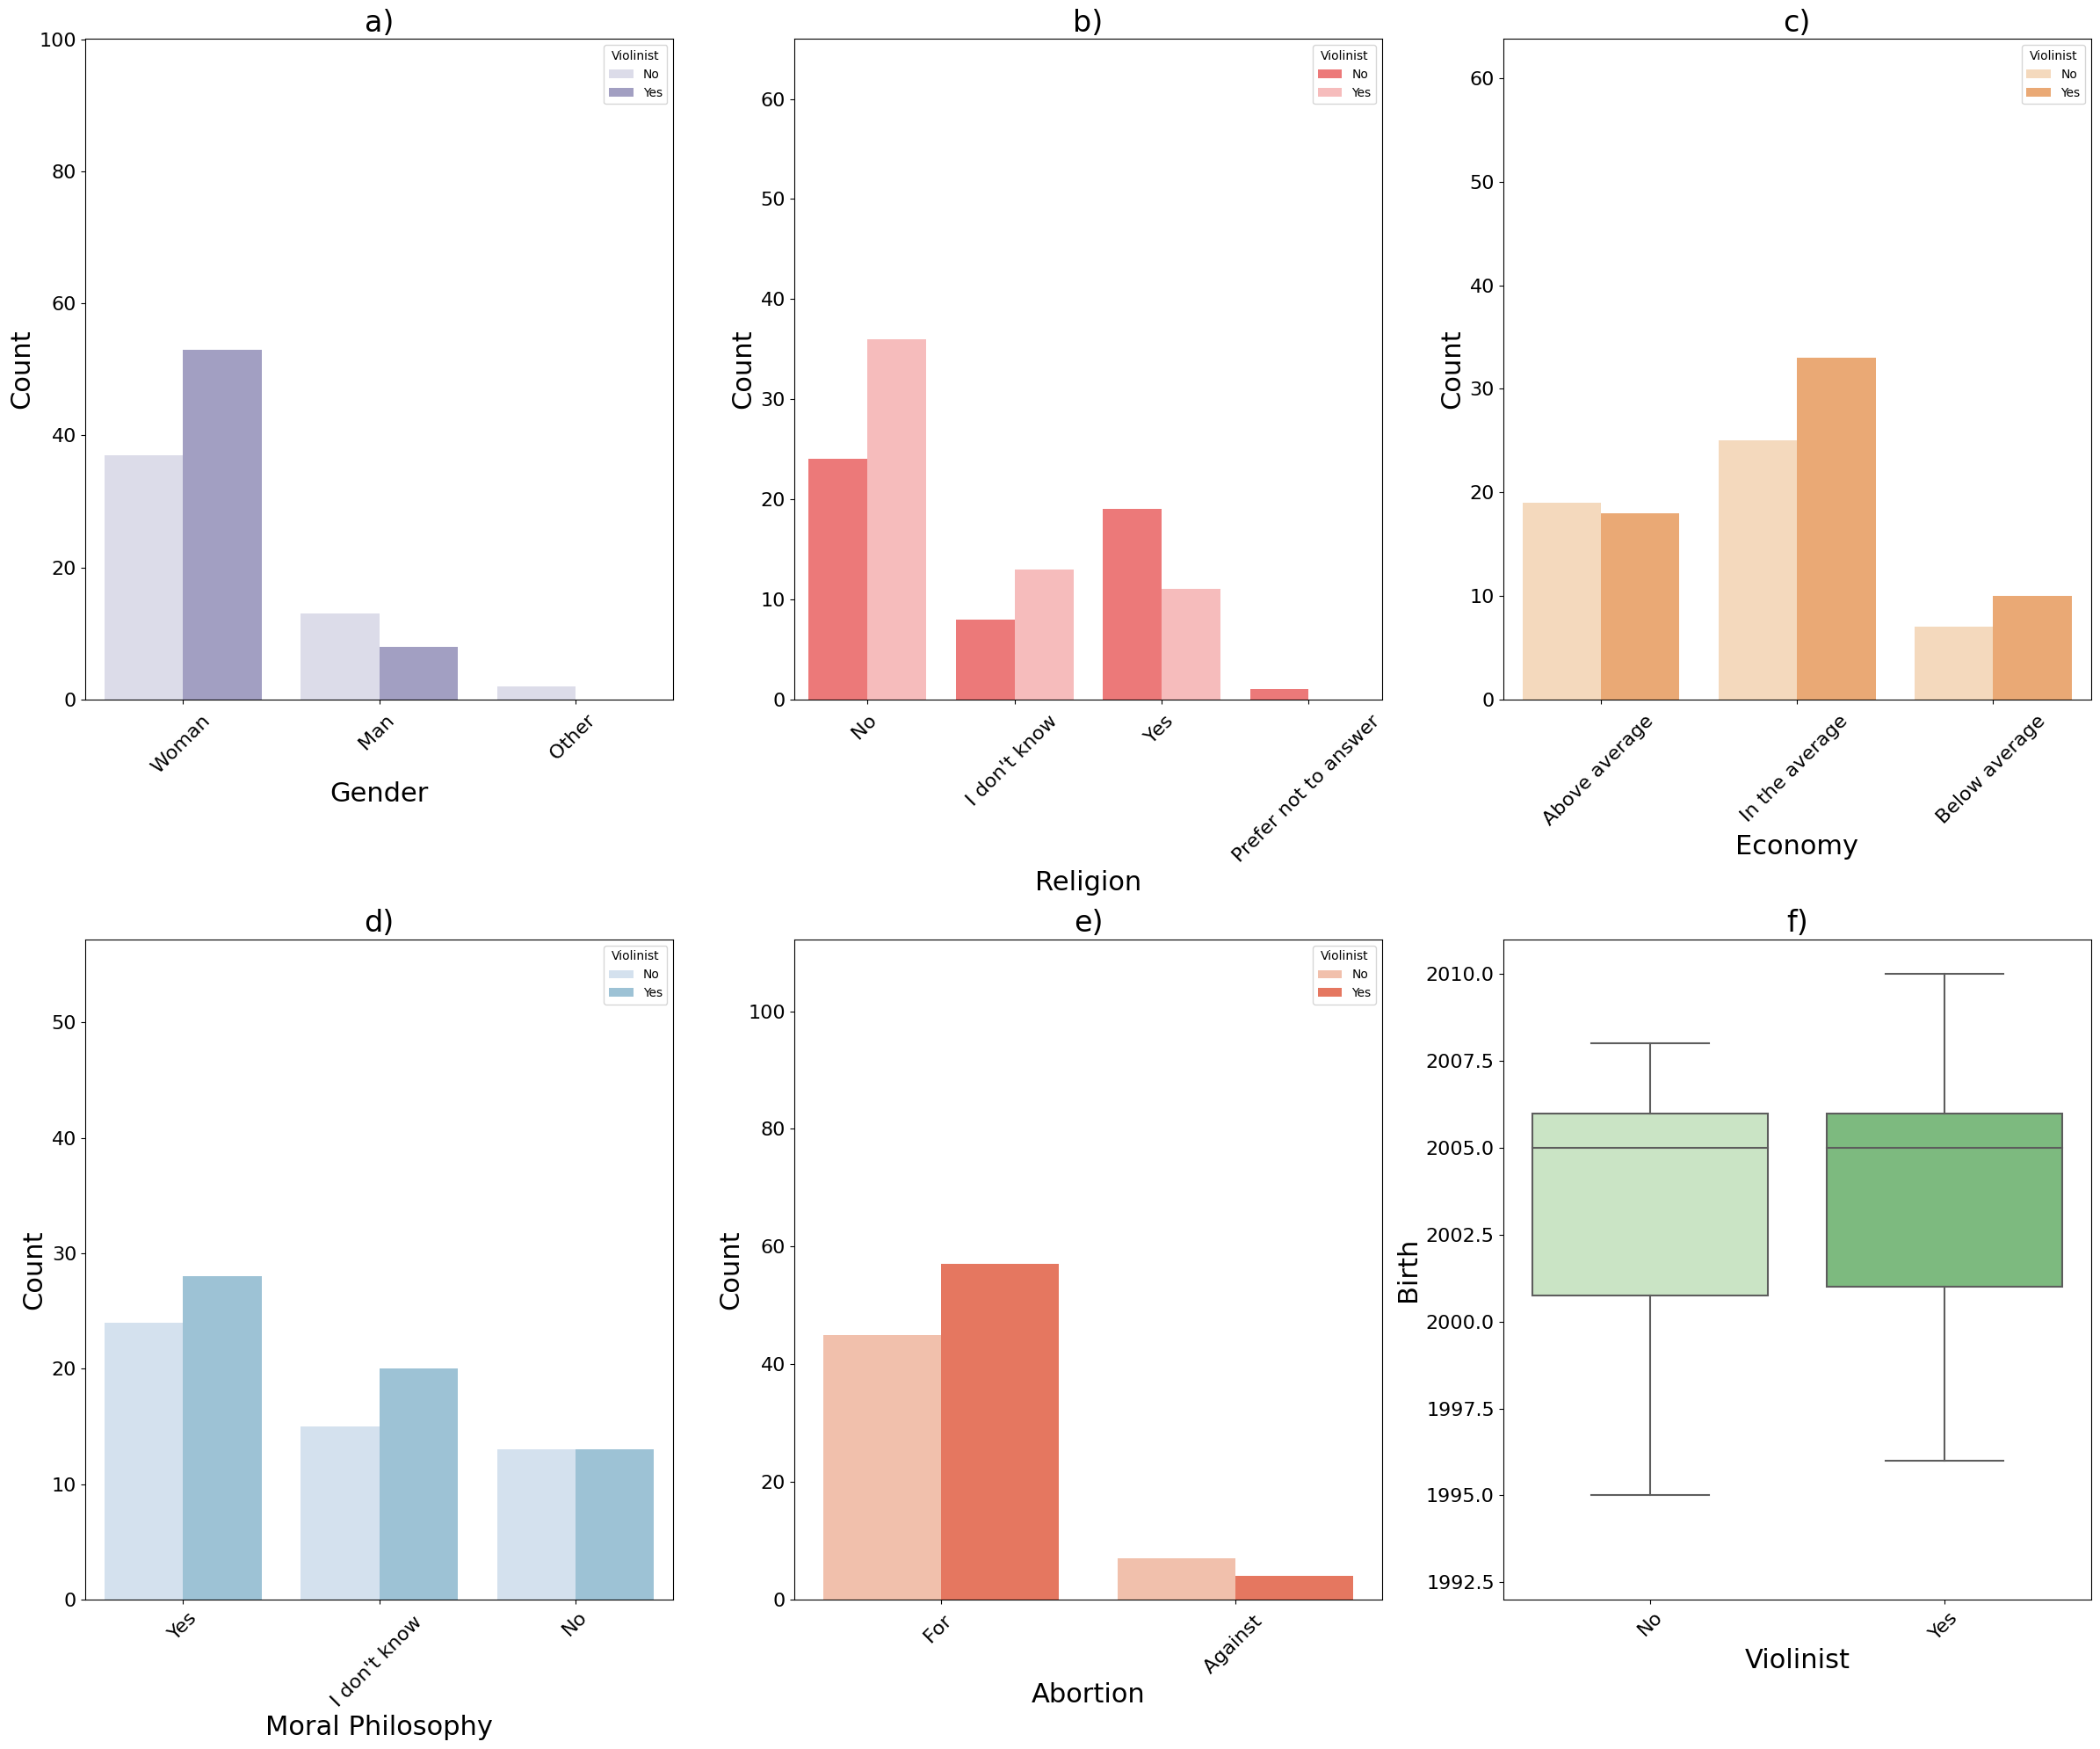

In [17]:
# Define the size of the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 20))

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'], errors='coerce')

# Catplot for Gender vs answers to the violinist experience of thought
gender_palette = sns.color_palette("Purples", len(df_clean['Gender'].unique()))
sns.countplot(x='Gender', hue='Violinist', data=df_clean, palette=gender_palette, ax=axes[0, 0])
axes[0, 0].set_title('a)', fontsize=24)
axes[0, 0].set_xlabel('Gender', fontsize=22)
axes[0, 0].set_ylabel('Count', fontsize=22)
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 0].tick_params(axis='y', labelsize=16)
axes[0, 0].set_ylim(0, df_clean['Gender'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Religion vs answers to the violinist experience of thought
vivid_reds = ["#FF6666", "#FFB3B3"]
religion_palette = sns.color_palette(vivid_reds, len(df_clean['Religion'].unique()))
sns.countplot(x='Religion', hue='Violinist', data=df_clean, palette=religion_palette, ax=axes[0, 1])
axes[0, 1].set_title('b)', fontsize=24)
axes[0, 1].set_xlabel('Religion', fontsize=22)
axes[0, 1].set_ylabel('Count', fontsize=22)
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 1].tick_params(axis='y', labelsize=16)
axes[0, 1].set_ylim(0, df_clean['Religion'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Economy vs answers to the violinist experience of thought
economy_palette = sns.color_palette("Oranges", len(df_clean['Economy'].unique()))
sns.countplot(x='Economy', hue='Violinist', data=df_clean, palette=economy_palette, ax=axes[0, 2])
axes[0, 2].set_title('c)', fontsize=24)
axes[0, 2].set_xlabel('Economy', fontsize=22)
axes[0, 2].set_ylabel('Count', fontsize=22)
axes[0, 2].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 2].tick_params(axis='y', labelsize=16)
axes[0, 2].set_ylim(0, df_clean['Economy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Moral Philosophy vs answers to the violinist experience of thought
moral_palette = sns.color_palette("Blues", len(df_clean['Moral_Philosophy'].unique()))
sns.countplot(x='Moral_Philosophy', hue='Violinist', data=df_clean, palette=moral_palette, ax=axes[1, 0])
axes[1, 0].set_title('d)', fontsize=24)
axes[1, 0].set_xlabel('Moral Philosophy', fontsize=22)
axes[1, 0].set_ylabel('Count', fontsize=22)
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 0].tick_params(axis='y', labelsize=16)
axes[1, 0].set_ylim(0, df_clean['Moral_Philosophy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Abortion vs answers to the violinist experience of thought
abortion_palette = sns.color_palette("Reds", len(df_clean['Abortion'].unique()))
sns.countplot(x='Abortion', hue='Violinist', data=df_clean, palette=abortion_palette, ax=axes[1, 1])
axes[1, 1].set_title('e)', fontsize=24)
axes[1, 1].set_xlabel('Abortion', fontsize=22)
axes[1, 1].set_ylabel('Count', fontsize=22)
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 1].tick_params(axis='y', labelsize=16)
axes[1, 1].set_ylim(0, df_clean['Abortion'].value_counts().max() * 1.1)  # adjust y-scale

# Boxplot for Birth vs answers to the violinist experience of thought
birth_palette = sns.color_palette("Greens", len(df_clean['Violinist'].unique()))
sns.boxplot(x='Violinist', y='Birth', data=df_clean, palette=birth_palette, ax=axes[1, 2])
axes[1, 2].set_title('f)', fontsize=24)
axes[1, 2].set_xlabel('Violinist', fontsize=22)
axes[1, 2].set_ylabel('Birth', fontsize=22)
axes[1, 2].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 2].tick_params(axis='y', labelsize=16)
axes[1, 2].set_ylim(1992, 2011)  # Set y-axis limit

# Adjust the spacing between subplots to avoid overlap of titles and labels
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

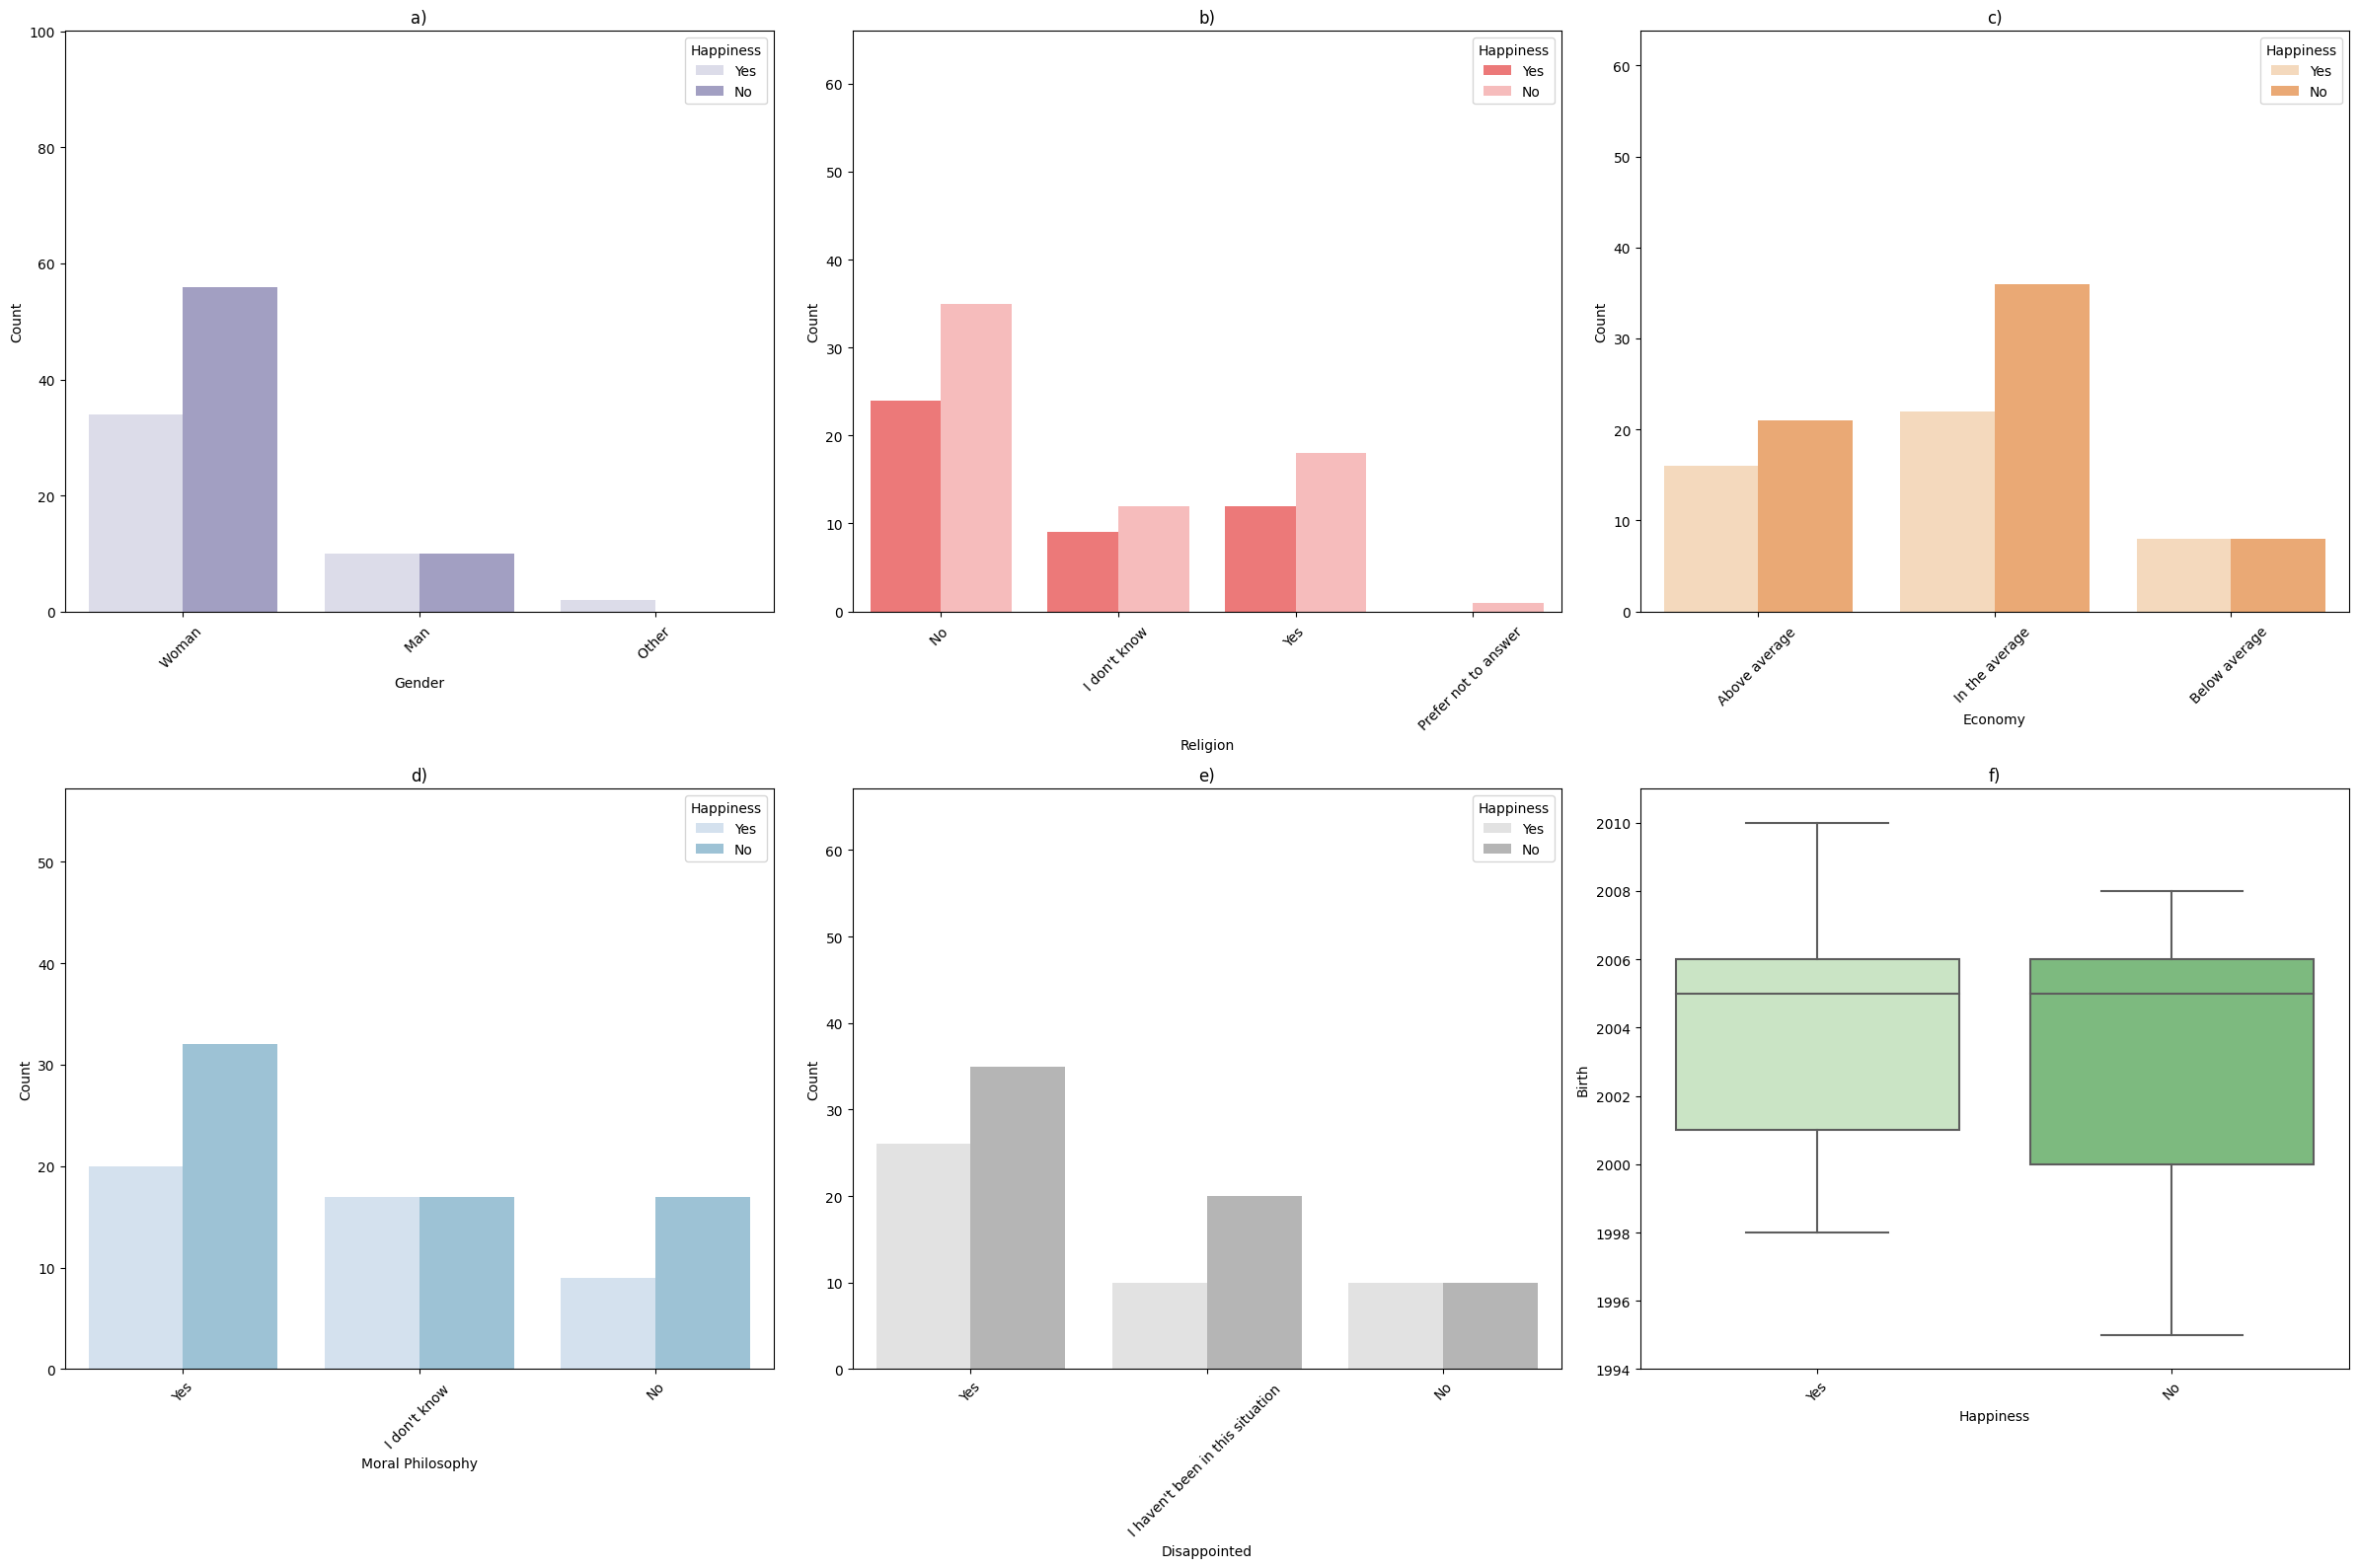

In [8]:
# Define the size of the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))
#fig.suptitle("Figure 3", fontsize=25)

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'], errors='coerce')

# Catplot for Gender vs answers to the machine of happiness thought experience
gender_palette = sns.color_palette("Purples", len(df_clean['Gender'].unique()))
sns.countplot(x='Gender', hue='Happiness', data=df_clean, palette=gender_palette, ax=axes[0, 0])
axes[0, 0].set_title('a)')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim(0, df_clean['Gender'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Religion vs answers to the machine of happiness thought experience
vivid_reds = ["#FF6666", "#FFB3B3"]
religion_palette = sns.color_palette(vivid_reds, len(df_clean['Religion'].unique()))
sns.countplot(x='Religion', hue='Happiness', data=df_clean, palette=religion_palette, ax=axes[0, 1])
axes[0, 1].set_title('b)')
axes[0, 1].set_xlabel('Religion')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim(0, df_clean['Religion'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Economy vs answers to the machine of happiness thought experience
economy_palette = sns.color_palette("Oranges", len(df_clean['Economy'].unique()))
sns.countplot(x='Economy', hue='Happiness', data=df_clean, palette=economy_palette, ax=axes[0, 2])
axes[0, 2].set_title('c)')
axes[0, 2].set_xlabel('Economy')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].set_ylim(0, df_clean['Economy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Moral Philosophy vs answers to the machine of happiness thought experience
moral_palette = sns.color_palette("Blues", len(df_clean['Moral_Philosophy'].unique()))
sns.countplot(x='Moral_Philosophy', hue='Happiness', data=df_clean, palette=moral_palette, ax=axes[1, 0])
axes[1, 0].set_title('d)')
axes[1, 0].set_xlabel('Moral Philosophy')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, df_clean['Moral_Philosophy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Disappointed vs answers to the machine of happiness thought experience
disappointed_palette = sns.color_palette("Greys", len(df_clean['Disappointed'].unique()))
sns.countplot(x='Disappointed', hue='Happiness', data=df_clean, palette=disappointed_palette, ax=axes[1, 1])
axes[1, 1].set_title('e)')
axes[1, 1].set_xlabel('Disappointed')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim(0, df_clean['Disappointed'].value_counts().max() * 1.1)  # adjust y-scale

# Boxplot for Birth vs answers to the machine of happiness thought experience
birth_palette = sns.color_palette("Greens", len(df_clean['Happiness'].unique()))
sns.boxplot(x='Happiness', y='Birth', data=df_clean, palette=birth_palette, ax=axes[1, 2])
axes[1, 2].set_title('f)')
axes[1, 2].set_xlabel('Happiness')
axes[1, 2].set_ylabel('Birth')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_ylim(1994, 2011)  # Set y-axis limit

# Adjust the spacing between subplots to avoid overlap of titles and labels
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. 

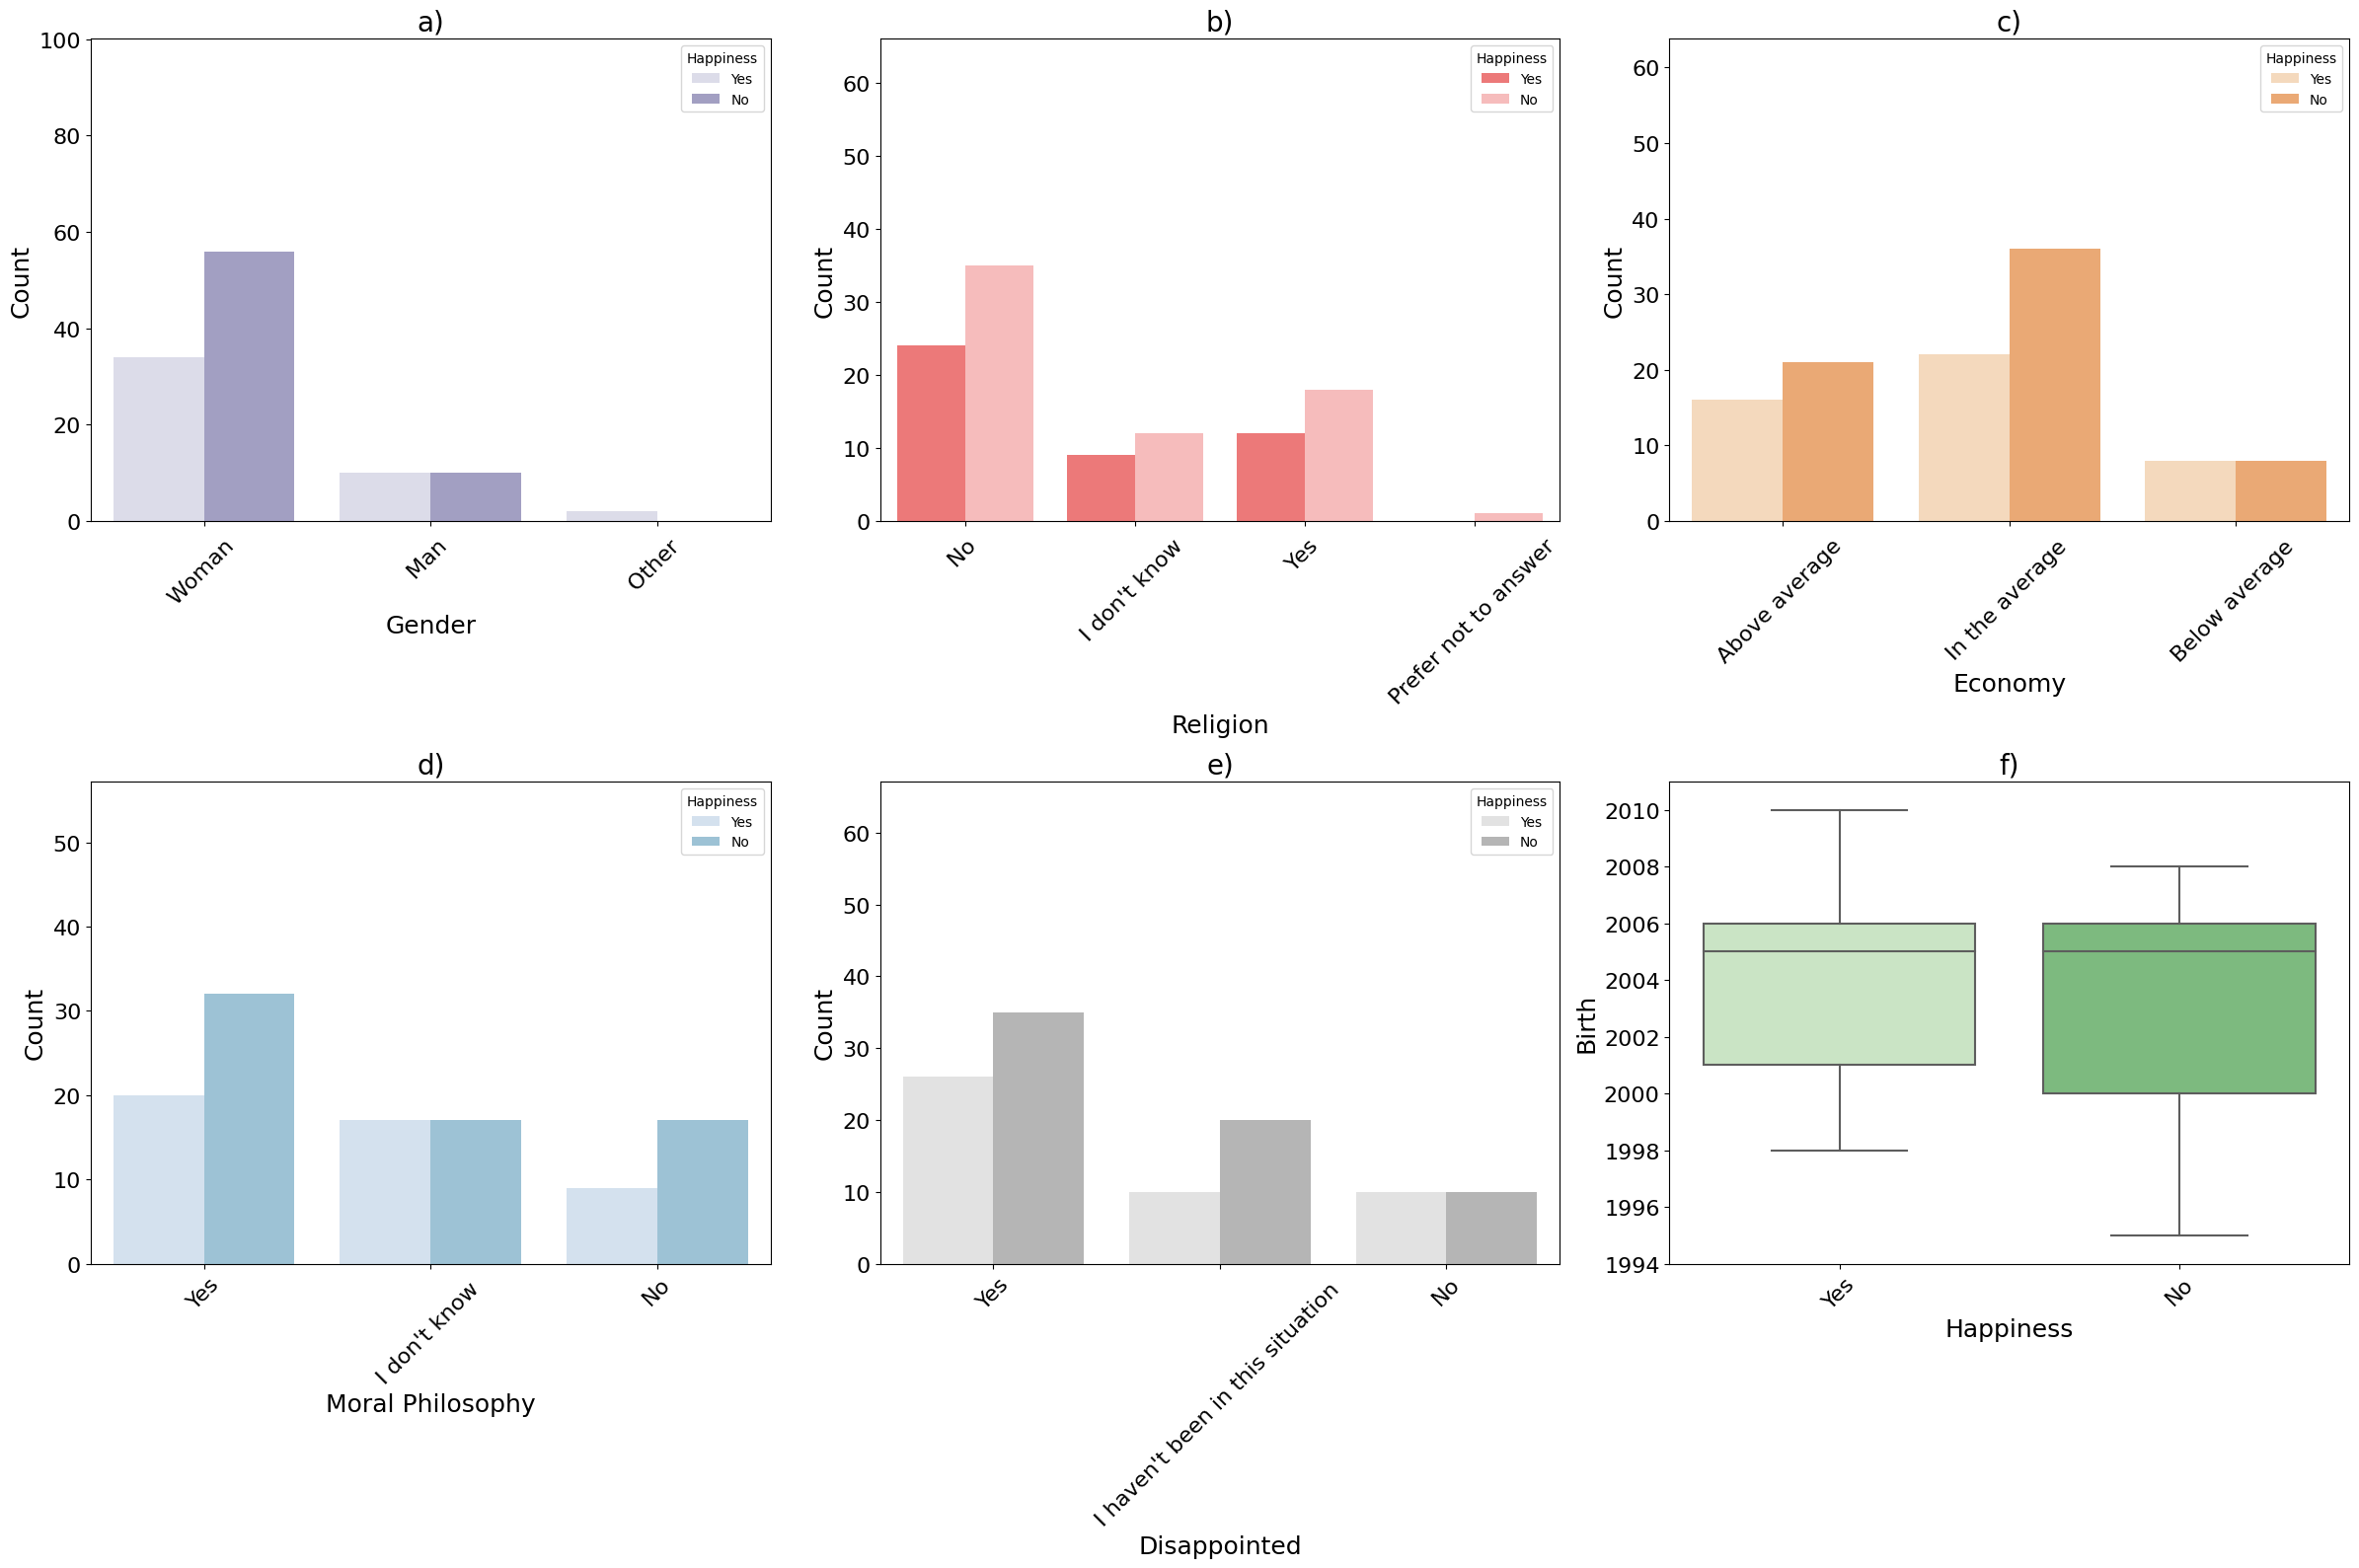

In [18]:
# Define the size of the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))

# Replace 'nan' strings with pandas NA values
df_clean = df.replace('nan', pd.NA)

# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'], errors='coerce')

# Catplot for Gender vs answers to the machine of happiness thought experience
gender_palette = sns.color_palette("Purples", len(df_clean['Gender'].unique()))
sns.countplot(x='Gender', hue='Happiness', data=df_clean, palette=gender_palette, ax=axes[0, 0])
axes[0, 0].set_title('a)', fontsize=20)
axes[0, 0].set_xlabel('Gender', fontsize=18)
axes[0, 0].set_ylabel('Count', fontsize=18)
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 0].tick_params(axis='y', labelsize=16)
axes[0, 0].set_ylim(0, df_clean['Gender'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Religion vs answers to the machine of happiness thought experience
vivid_reds = ["#FF6666", "#FFB3B3"]
religion_palette = sns.color_palette(vivid_reds, len(df_clean['Religion'].unique()))
sns.countplot(x='Religion', hue='Happiness', data=df_clean, palette=religion_palette, ax=axes[0, 1])
axes[0, 1].set_title('b)', fontsize=20)
axes[0, 1].set_xlabel('Religion', fontsize=18)
axes[0, 1].set_ylabel('Count', fontsize=18)
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 1].tick_params(axis='y', labelsize=16)
axes[0, 1].set_ylim(0, df_clean['Religion'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Economy vs answers to the machine of happiness thought experience
economy_palette = sns.color_palette("Oranges", len(df_clean['Economy'].unique()))
sns.countplot(x='Economy', hue='Happiness', data=df_clean, palette=economy_palette, ax=axes[0, 2])
axes[0, 2].set_title('c)', fontsize=20)
axes[0, 2].set_xlabel('Economy', fontsize=18)
axes[0, 2].set_ylabel('Count', fontsize=18)
axes[0, 2].tick_params(axis='x', rotation=45, labelsize=16)
axes[0, 2].tick_params(axis='y', labelsize=16)
axes[0, 2].set_ylim(0, df_clean['Economy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Moral Philosophy vs answers to the machine of happiness thought experience
moral_palette = sns.color_palette("Blues", len(df_clean['Moral_Philosophy'].unique()))
sns.countplot(x='Moral_Philosophy', hue='Happiness', data=df_clean, palette=moral_palette, ax=axes[1, 0])
axes[1, 0].set_title('d)', fontsize=20)
axes[1, 0].set_xlabel('Moral Philosophy', fontsize=18)
axes[1, 0].set_ylabel('Count', fontsize=18)
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 0].tick_params(axis='y', labelsize=16)
axes[1, 0].set_ylim(0, df_clean['Moral_Philosophy'].value_counts().max() * 1.1)  # adjust y-scale

# Catplot for Disappointed vs answers to the machine of happiness thought experience
disappointed_palette = sns.color_palette("Greys", len(df_clean['Disappointed'].unique()))
sns.countplot(x='Disappointed', hue='Happiness', data=df_clean, palette=disappointed_palette, ax=axes[1, 1])
axes[1, 1].set_title('e)', fontsize=20)
axes[1, 1].set_xlabel('Disappointed', fontsize=18)
axes[1, 1].set_ylabel('Count', fontsize=18)
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 1].tick_params(axis='y', labelsize=16)
axes[1, 1].set_ylim(0, df_clean['Disappointed'].value_counts().max() * 1.1)  # adjust y-scale

# Boxplot for Birth vs answers to the machine of happiness thought experience
birth_palette = sns.color_palette("Greens", len(df_clean['Happiness'].unique()))
sns.boxplot(x='Happiness', y='Birth', data=df_clean, palette=birth_palette, ax=axes[1, 2])
axes[1, 2].set_title('f)', fontsize=20)
axes[1, 2].set_xlabel('Happiness', fontsize=18)
axes[1, 2].set_ylabel('Birth', fontsize=18)
axes[1, 2].tick_params(axis='x', rotation=45, labelsize=16)
axes[1, 2].tick_params(axis='y', labelsize=16)
axes[1, 2].set_ylim(1994, 2011)  # Set y-axis limit

# Adjust the spacing between subplots to avoid overlap of titles and labels
plt.tight_layout()

# Display the plot
plt.show()


## 5. Data Modelling

In [9]:
df_clean = df.copy()


In [10]:
# Select variables for logistic regression (replace with correct variables)
df_clean = df_clean[['Violinist', 'Economy', 'Gender', 'Moral_Philosophy', 'Religion', 'Birth', 'Happiness']]

# Transform values in 'Violinist' to 0/1 variables
df_clean['Violinist'] = df_clean['Violinist'].map({'Yes': 1, 'No': 0})

# Transform values in 'Happiness' to 0/1 variables
df_clean['Happiness'] = df_clean['Happiness'].map({'Yes': 1, 'No': 0})

# Transform values in 'Economy' to 0/1/2 variables
economy_map = {'Below average ': 0, 'In the average ': 1, 'Above average ': 2}
df_clean['Economy'] = df_clean['Economy'].map(economy_map)

# Transform values in 'Gender' to 0/1 variables
gender_map = {'Man ': 0, 'Woman ': 1}
df_clean['Gender'] = df_clean['Gender'].map(gender_map)

# Transform values in 'Religion' to 0/1/2 variables
religion_map = {'No ': 0, 'Prefer not to say ': 1, 'Yes ': 2}
df_clean['Religion'] = df_clean['Religion'].map(religion_map)

# Transform values in 'Moral_Philosophy' to 0/1 variables
moral_philosophy_map = {'No': 0, "I don't know": 0, 'Yes': 1}
df_clean['Moral_Philosophy'] = df_clean['Moral_Philosophy'].map(moral_philosophy_map)


###  Statistical test of multivariate logistic regression between the theoretical case of the happiness machine and its confounding variables

In [11]:
# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'])

# Fit the multiple logistic regression model
model = smf.logit('Violinist ~ Economy + Gender + Religion + Moral_Philosophy + Birth', data=df_clean).fit()

# Display the regression results
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.585361
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Violinist   No. Observations:                   59
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            5
Date:                Mon, 30 Sep 2024   Pseudo R-squ.:                  0.1511
Time:                        22:10:09   Log-Likelihood:                -34.536
converged:                       True   LL-Null:                       -40.684
Covariance Type:            nonrobust   LLR p-value:                   0.03097
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.2116     65.941      0.064      0.949    -125.030     133.453
Economy    

### Statistical test of multivariate logistic regression between the theoretical case of the happiness machine and its confounding variables

In [12]:
# Convert the 'Birth' column to numeric
df_clean['Birth'] = pd.to_numeric(df_clean['Birth'])

# Fit the multiple logistic regression model
model = smf.logit('Happiness ~ Economy + Gender + Religion + Moral_Philosophy + Birth', data=df_clean).fit()

# Display the regression results
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.649561
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              Happiness   No. Observations:                   59
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            5
Date:                Mon, 30 Sep 2024   Pseudo R-squ.:                 0.03863
Time:                        22:10:09   Log-Likelihood:                -38.324
converged:                       True   LL-Null:                       -39.864
Covariance Type:            nonrobust   LLR p-value:                    0.6876
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           41.6521     58.759      0.709      0.478     -73.513     156.817
Economy    

### Statistical test of the square chi between the theoretical case of the violinist and the real case of abortion

In [13]:
# Replace "I don't know" with "Against" in the 'Abortion' column
df['Abortion'] = df['Abortion'].replace("I don't know ", "Against ")

# Create the contingency table
contingency_table = pd.crosstab(df['Abortion'], df['Violinist'])

# Display the contingency table
print("Contingency Table:\n", contingency_table)

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display the results
print("\nChi-Square Test")
print(f"Chi2: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)


Contingency Table:
 Violinist  No  Yes
Abortion          
Against     7    4
For        45   57

Chi-Square Test
Chi2: 0.8384151909646125
P-value: 0.3598504206733488
Degrees of freedom: 1
Expected frequencies:
 [[ 5.0619469  5.9380531]
 [46.9380531 55.0619469]]


### Statistical test of the Chi square between the theoretical case of the happiness machine and the real case of the lie with good intentions

In [14]:
# Create the contingency table
contingency_table = pd.crosstab(df['Happiness'], df['Disappointed'])

# Display the contingency table
print("Contingency Table:\n", contingency_table)

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display the results
print("\nChi-Square Test")
print(f"Chi2: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)


Contingency Table:
 Disappointed  I haven't been in this situation   No  Yes
Happiness                                               
No                                           20  10   35
Yes                                          10  10   26

Chi-Square Test
Chi2: 1.4514776029387566
P-value: 0.4839668813984783
Degrees of freedom: 2
Expected frequencies:
 [[17.56756757 11.71171171 35.72072072]
 [12.43243243  8.28828829 25.27927928]]
